##Convolutional Neural Networks



# **1. Pengenalan**

Praktikum ini menjelaskan bagaimana klasifikasi gambar pada data CIFAR-10 dataset. Pada praktikum ini akan dibuat sebuah classifier gambar dengan model Sequential `tf.keras.Sequential` dan load data menggunakan `tf.keras.preprocessing.image.ImageDataGenerator`. Anda akan memperoleh pengalaman sebagai berikut:

* Membangun _data input pipelines_ menggunakan `tf.keras.preprocessing.image.ImageDataGenerator` class untuk bekerja secara efisien dengan data pada disk untuk digunakan dengan model.
* _Overfitting_ —Bagaimana mencegah terjadinya overfitting.
* _Data augmentation_ and _dropout_ —Teknik-teknik utama untuk melawan overfitting dalam tugas-tugas Computer Vision untuk diintegrasikan ke dalam alur data dan model klasifikasi gambar.

Pekerjaan lab ini mengikuti alur kerja pembelajaran mesin dasar:

1. Memeriksa dan memahami data
2. Membangun alur input/masukan
3. Membangun model
4. Melatih model
5. Menguji model
6. Memperbaiki model dan mengulangi prosesnya

# **2. Mounting Google Drive**

In [ ]:
from google.colab import drive
from os.path import join, exists

# mounting dataset dari gdrive
drive.mount('/content/gdrive', force_remount=True)

# folder ini juga digunakan untuk menyimpan model yang sudah dilatih
root_path = 'gdrive/My Drive/Colab Notebooks/Deep Learning Labs/Prak04_Data/'

# opsional - tampilkan info lokasi dataset
print("Path root:", root_path)

Mounted at /content/gdrive
Path root: gdrive/My Drive/Colab Notebooks/Deep Learning Labs/Prak04_Data/


# **3. Download Dataset**
Kita menggunakan CIFAR-10 Dataset yang terdiri 10 kelas.

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

# download Cifar-10 dataset
(X_data, y_data), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# kategori pada dataset
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# bagi data latih untuk mendapatkan data validasi dengan rasio 70% - 30%
X_train, X_val, y_train, y_val = train_test_split(X_data, y_data,
                                                  test_size=0.3,
                                                  random_state=42)

y_train = y_train.ravel()
y_val = y_val.ravel()
y_test = y_test.ravel()

# tampilkan informasi dataset
num_class = len(class_names)

print('Jumlah kelas:', num_class)
print('Label kelas:', class_names)
print('Dimensi data latih:', X_train.shape)
print('Dimensi data validasi:', X_val.shape)
print('Dimensi data uji:', X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Jumlah kelas: 10
Label kelas: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Dimensi data latih: (35000, 32, 32, 3)
Dimensi data validasi: (15000, 32, 32, 3)
Dimensi data uji: (10000, 32, 32, 3)


## Visualisasi data

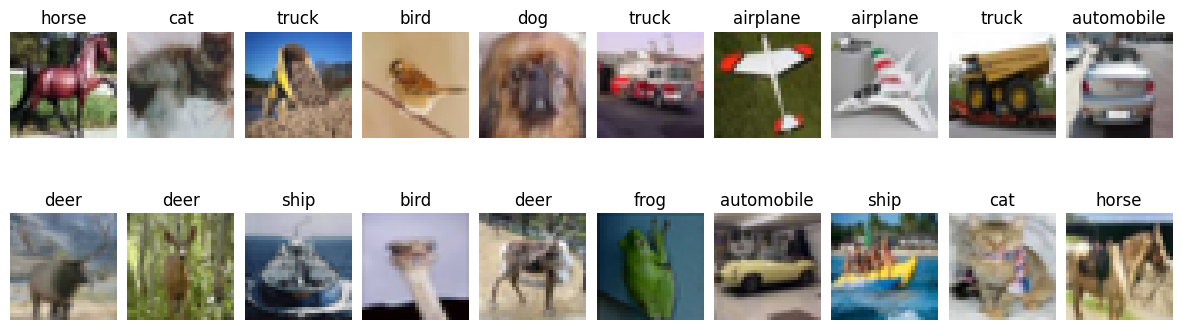

In [ ]:
import matplotlib.pyplot as plt

%matplotlib inline

fig, ax = plt.subplots(2,10,figsize=(15,4.5))
fig.subplots_adjust(hspace=0.1, wspace=0.1)
for j in range(0,2):
    for i in range(0, 10):
        ax[j,i].imshow(X_train[i+j*10])
        ax[j,i].set_title(class_names[y_train[i+j*10]])
        ax[j,i].axis('off')
plt.show()

## Persiapkan dataset
Sebelumnya gambar-gambar harus di pre-process terlebih dahulu menjadi tensor yang mengandung angka-angka bilangan real (floating point) sebelum digunakan pada neural networks.

1. Baca gambar-gambar dari disk.
2. Decode isi dari gambar-gambar tersebut dan ubah menjadi grid format yang seusai dengan nilai RGB mereka.
3. Ubah menjadi floating point tensors
4. Rescale tensornya dari range 0 sampai 255 menjadi angka-angka pada range 0 dan 1, karena neural networks lebih prefer input dengan range nilai yang kecil. Penting bahwa training set dan test set harus diproses terlebih dahulu dengan cara yang sama.

Untungnya, semua langkah di atas dapat dilakukan dengan kelas `ImageDataGenerator` yang disediakan oleh `tf.keras`. Kelas tersebut dapat membaca gambar dari disk dan memprosesnya terlebih dahulu menjadi tensor yang tepat. Ia juga akan menyiapkan generator yang mengubah gambar-gambar ini menjadi kumpulan tensor saat melatih jaringan.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# input citra
input_size = (X_train[0].shape[0], X_train[0].shape[1], 3)

# ukuran batch
batch_size = 128

# inisialisasi generator data latih dengan augmentasi data
train_image_generator = ImageDataGenerator(rescale=1./255)

# inisialisasi generator data validasi
val_image_generator = ImageDataGenerator(rescale=1./255)

 # inisialisasi generator data uji
test_data_generator = ImageDataGenerator(rescale=1./255)

# buat generator data latih
train_data_gen = train_image_generator.flow(X_train, y_train,
                                            batch_size=batch_size,
                                            shuffle=True)
# buat generator data validasi
val_data_gen = val_image_generator.flow(X_val, y_val,
                                        batch_size=batch_size,
                                        shuffle=True)
# buat generator data uji
test_data_gen = test_data_generator.flow(X_test, y_test,
                                         batch_size=1,
                                         shuffle=True)

# **4. Membangun Model CNN**



Sebuah convolutional neural networks yang sederhana terdiri dari serangkaian layer, dan setiap layer mentransformasi satu volume aktivasi kepada aktivasi yang lainnya melalui fungsi yang "differentiable". Kita akan menggunakan tiga jenis layer untuk membangun Covolutional Neural Networks: **Convolutional Layer, Pooling Layer, dan Fully Connected Layer**. Kita akan menumpuk (stacking) layer-layer tersebut untuk membentuk arsitektur ConvNet yang full.

## **CNN Model**
 Sebuah arsitektur ConvNet sederhana untuk klasifikasi gambar pada dataset CIFAR-10 memiliki layer-layer sebagai berikut:
`[INPUT - CONV - RELU - POOL - FC]`


Lebih detail:

1. **INPUT** [32x32x3]
memegang nilai raw pixel dari gambar, dalam hal ini gambar berukuran lebar 32, tinggi 32, dan tiga channel warna yaitu R,G,B.
2. **CONV layer**
akan menghitung output dari neuron-neuron yang terkoneksi dengan input, komputasi yang dilakukan adalah dot product antara weights pada neuron dengan 'a small region' yang terhubung dengan input.

Contoh, hasilnya akan berukuran [32x32x12] jika kita menggunakan 12 filters.

<table>
  <tr><td  align="center">
    <img src="https://miro.medium.com/max/960/1*bx3kWA2cKm14OrNP1M-6gw.gif" width="80%"
         alt="Convolution Process">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1:</b> Convolution Process.<br/>
  </td></tr>
</table>

3. **RELU layer**
akan mengaplikasikan elementwise activation function, misalnya fungsi max(0,x) untuk memberlakukan thresholding 0. Hal ini tidak membawa perubahan pada ukuran output ([32x32x12]).
4. **POOL layer**
akan melakukan 'a downsampling operation' (downsampling = mengurangi jumlah sample) sepanjang dimensi spasial (lebar, tinggi), menghasilkan perubahan ukuran pada output, misalnya [16x16x12].
5. **FC (i.e. fully-connected) layer**
akan menghitung skor setiap kelas pada target class, menghasilkan output dengan ukuran [1x1x10], dimana setiap angka dari 10 angka tersebut merupakan skor dari sebuah kelas, yang merupakan target class pada dataset CIFAR-10. Setiap neuron pada layer ini (sebagaimana namanya Fully Connected Layer) terhubung (connected) dengan setiap neuron di layer sebelumnya.

Dengan cara ini, ConvNets mengubah gambar input (gambar asal) layer by layer dari pixel aslinya menjadi skor setiap kelas pada target class. Perlu dicatat bahwa setiap layer memiliki parameter masing-masing. Secara khusus, lapisan CONV/FC melakukan transformasi dengan fungsi-fungsi yang tidak hanya aktivasi dari input, tetapi juga fungsi-fungsi dengan parameter (bobot/weight dan bias neuron).

Di sisi lain, layer RELU/POOL mengimplementasi fixed function. Parameter dalam lapisan CONV/FC akan dilatih dengan Gradient Descent sehingga skor kelas yang dihitung oleh ConvNet konsisten dengan label/target class dalam training set untuk setiap gambar.

## Contoh Model CNN

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D, Dense
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.layers import MaxPooling2D, Activation, Flatten
from tensorflow.keras.optimizers import Adam

## Buat model CNN dengan konfigurasi sebagai berikut:

**Convolutional block 1**
- conv layer dengan jumlah filter = 32, ukuran filter = 3x3, fungsi aktivasi relu
- conv layer dengan jumlah filter = 32, ukuran filter = 3x3, fungsi aktivasi relu
- max pooling layer dengan pooling size 2x2

**Convolutional block 2**
- conv layer dengan jumlah filter = 64, ukuran filter = 3x3, fungsi aktivasi relu
- conv layer dengan jumlah filter = 64, ukuran filter = 3x3, fungsi aktivasi relu
- max pooling layer dengan pooling size 2x2

**Convolutional block 3**
- conv layer dengan jumlah filter = 128, ukuran filter = 3x3, fungsi aktivasi relu
- conv layer dengan jumlah filter = 128, ukuran filter = 3x3, fungsi aktivasi relu
- max pooling layer dengan pooling size 2x2

**Flatten**

**Fully connected layer**
- Dense dengan jumlah neuron 128 dan fungsi aktivasi relu

**Output layer**
- Dense dengan jumlah neuron sejumlah kategori dari dataset CIFAR-10 dan fungsi aktivasi softmax

In [ ]:
cnn_model1 = Sequential()

# the first convolutional block
cnn_model1.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_size))
cnn_model1.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
# max pooling
cnn_model1.add(MaxPooling2D(pool_size=(2, 2)))

# the second convolutional block
cnn_model1.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
cnn_model1.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
# max pooling
cnn_model1.add(MaxPooling2D(pool_size=(2, 2)))

# the third convolutional block
cnn_model1.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
cnn_model1.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
# max pooling
cnn_model1.add(MaxPooling2D(pool_size=(2, 2)))

# flatten
cnn_model1.add(Flatten())

# fully connected layer
cnn_model1.add(Dense(128, activation='relu'))

# last layer untuk klasifikasi gambar
cnn_model1.add(Dense(num_class, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile the model

Sebelum model siap untuk ditraining, Beberapa setting perlu dilakukan. Setting ini dilakukan pada fungsi model.compile:

*Loss function* — Fungsi untuk mengukur seberapa akurat model selama training. Kita ingin meminimalkan fungsi ini untuk "mengarahkan" model ke arah yang benar, yaitu memiliki performa yang maksimal.

*Optimizer* — Fungsi bagaimana model diupdate berdasarkan data yang dilihat dan berdasarkan loss function.

*Metrics* — Metrics digunakan untuk memonitor step-step training dan testing. Salah satu contohnya adalah 'accuracy', yaitu jumlah gambar yang dapat diprediksi dengan benar.

Pada praktikum ini kita akan menggunakan *ADAM* optimizer dan *binary cross entropy* untuk loss function. Untuk melihat akurasi training dan validasi pada setiap epoch, gunakan argumen `metrics`.

In [ ]:
# Path to save the best model.
checkpoint_filepath = join(root_path, 'cnn_model1.h5')

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath, save_weights_only=False,
    monitor='val_loss', verbose=1, mode='auto', save_best_only=True)

opt = keras.optimizers.Adam(learning_rate=0.0001) # '1e-4' bisa diisi dengan ini

cnn_model1.compile(optimizer=opt,
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

### Model summary

Melihat summary dari setiap layer pada neural networks:

In [ ]:
cnn_model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

# **5. Pelatihan Model CNN**
Training the neural network model requires the following steps:

1. Masukkan training data ke model. Pada contoh ini, training data terdapat pada  array ```train_images``` dan ```train_labels``` .

2. The model belajar untuk mengasosiasikan gambar dengan label/target class.

3. Dataset untuk pengujian (testing) terdapat pada array ```test_images``` .

4. Verifikasi apakah hasil prediksi sesuai dangan label pada ```test_labels``` array.

Untuk memulai training, panggil  ```model.fit```

In [ ]:
epochs = 5

history = cnn_model1.fit(
    train_data_gen,
    epochs=epochs,
    validation_data=val_data_gen,
    callbacks=[model_checkpoint_callback],
    verbose=1)

Epoch 1/5
270/274 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4387 - loss: 1.5779
Epoch 1: val_loss improved from inf to 1.47356, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/Prak04_Data/cnn_model1.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4387 - loss: 1.5773 - val_accuracy: 0.4710 - val_loss: 1.4736
Epoch 2/5
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4732 - loss: 1.4467
Epoch 2: val_loss improved from 1.47356 to 1.39562, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/Prak04_Data/cnn_model1.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4733 - loss: 1.4465 - val_accuracy: 0.4927 - val_loss: 1.3956
Epoch 3/5
271/274 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5211 - loss: 1.3279
Epoch 3: val_loss improved from 1.39562 to 1.31706, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/Prak04_Data/cnn_model1.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5211 - loss: 1.3279 - val_accuracy: 0.5273 - val_loss: 1.3171
Epoch 4/5
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5471 - loss: 1.2656
Epoch 4: val_loss improved from 1.31706 to 1.24635, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/Prak04_Data/cnn_model1.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5472 - loss: 1.2655 - val_accuracy: 0.5563 - val_loss: 1.2464
Epoch 5/5
272/274 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5770 - loss: 1.2029
Epoch 5: val_loss improved from 1.24635 to 1.20212, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/Prak04_Data/cnn_model1.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5771 - loss: 1.2027 - val_accuracy: 0.5787 - val_loss: 1.2021


### Visualisasi Hasil Training
Visualisasi Hasil Training Convolutional Neural Networks.

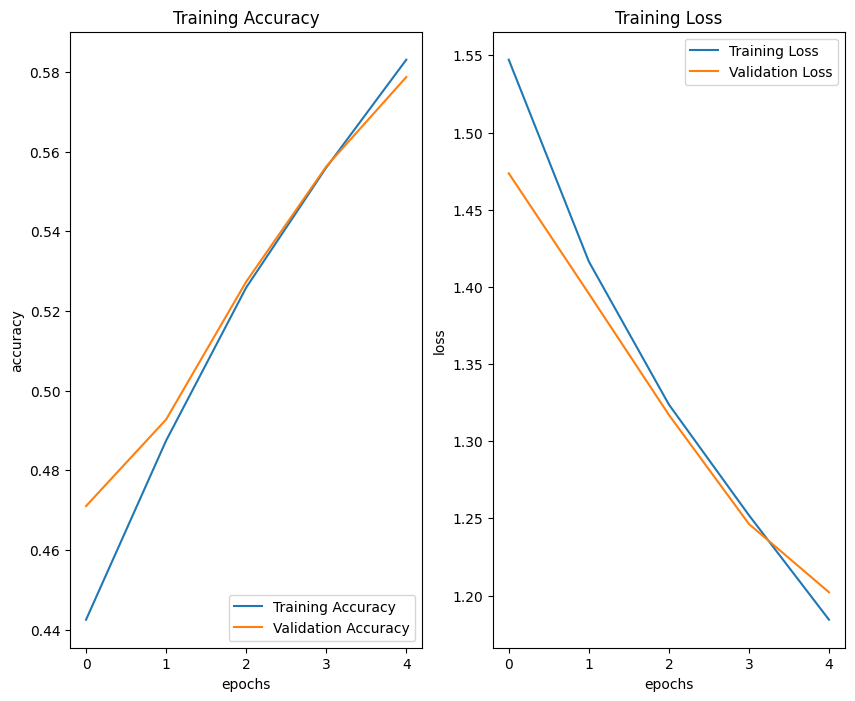

In [ ]:
# ambil statistik pelatihan
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs_range = range(epochs)

# plot hasil akurasi pelatihan
plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.title('Training Accuracy')

# plot hasil loss pelatihan
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.title('Training Loss')
plt.show()

Seperti yang dapat kita lihat pada plot, akurasi pada data training dan data validasi sangat berbeda jauh dan model hanya mencapai akurasi 70% pada dataset validasi.

Gap yang besar pada akurasi training dan validasi menunjukkan adanya OVERFITTING. Overfitting terjadi pada sebuah model machine learning jika akurasinya dalam memprediksi data-data baru lebih buruk daripada akurasinya pada data training.

Model yang mengalami overfitting lebih "mengingat" data training dan memiliki akurasi yang rendah pada data validasi.

Mari kita cek apa yang salah dan mencoba untuk menaikkan performa model.

# **6. Managing Overfitting**
Pada plot di atas, akurasi training meningkat secara linear terhadap waktu, sedangkan akurasi validasi masih berkisar pada nilai 70% selama proses training. Perbedaan akurasi ini dapat mengindikasikan terjadinya *overfitting*.

Jika terdapat hanya sedikit data pada data training, model terkadang belajar dari anomali atau detail yang tidak diinginkan dari data training—sehingga malah berdampak negatif pada kinerja model pada data baru. Fenomena ini dikenal sebagai overfitting. Ini berarti bahwa model akan kesulitan melakukan "generalisasi" pada dataset yang baru.

Ada beberapa cara untuk menangani overfitting pada proses training. Pada praktikum ini kita akan gunakan *data augmentation* dan menambahkan *dropout* pada model supaya dapat mengurangi overfitting.

## Augmentasi Data
Overfitting biasanya dapat terjadi jika data training hanya memiliki sedikit data. Salah satu cara untuk menangani overfitting adalah melakukan "augmentasi" (penambahan) dataset sehingga kita memiliki data training yang cukup. Augmentasi data dilakukan dengan menambah lebih banyak data training dari sampel training yang sudah ada dengan melakukan augmentasi sampel  menggunakan transformasi secara random/acak yang menghasilkan gambar yang tampak meyakinkan. Tujuannya adalah model tidak akan pernah melihat gambar yang sama persis dua kali selama training. Hal ini membantu memaparkan model ke lebih banyak aspek data sehingga menggeneralisasi dengan lebih baik.

Implementasi augmentasi data menggunakan `tf.keras` using the `ImageDataGenerator` class. Gunakan transformasi yang berbeda-beda pada dataset dan transformasi tersebut akan diaplikasikan selama training.

### Augmentasi dan Visualisasi data

Kita dapat menggunakan teknik "data augmentation" untuk menambah jumlah data pada training dataset, dengan membangkitkan data baru dari data yang sudah ada dengan mengaplikasikan transformasi random(sebagai contoh, rotasi).

Hal ini terutama efektif jika bekerja dengan gambar. Sebagai contoh, data training yang kita miliki hanya mengandung gambar-gambar kucing  that menghadap kanan. Maka, jika dataset validasi kita mengandung gambar kucing yang posisinya terbalik (kepala di bawah, badan di atas) model kita akan kesulitan dalam melakukan klasifikasi dengan tepat.

Augmentasi data dibangun dengan ImageDataGenerator. Anda dapat menggunakan berbagai jenis transformasi, dan akan diaplikasikan selama proses training.

Kita akan mulai dengan mengaplikasikan random horizontal flip pada dataset dan lihat bagaimana setiap gambar akan tampak setelah transformasi tersebut.

### Apply horizontal flip

Gunakan `horizontal_flip` sebagai argumen pada `ImageDataGenerator` class dan set `True` untuk mengaplikasikan augmentasi tersebut.

### Randomly rotate the image

Kita akan coba transformasi yang lain yaitu rotasi dan aplikasikan rotasi 20 derajat secara random pada data training.

### Apply zoom augmentation

Aplikasikan zoom augmentation pada dataset sehingga gambar akan di-zoom sampai 20% secara random.



In [ ]:
# buat prosedur augmentasi pada data
new_train_image_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    # width_shift_range=.1,
    # height_shift_range=.1,
    horizontal_flip=True,
    zoom_range=0.2)

# terapkan augmentasi pada data latih
new_train_data_gen = new_train_image_generator.flow(X_train, y_train,
                                            batch_size=batch_size,
                                            shuffle=True)

Tampilkan hasil augmentasi data

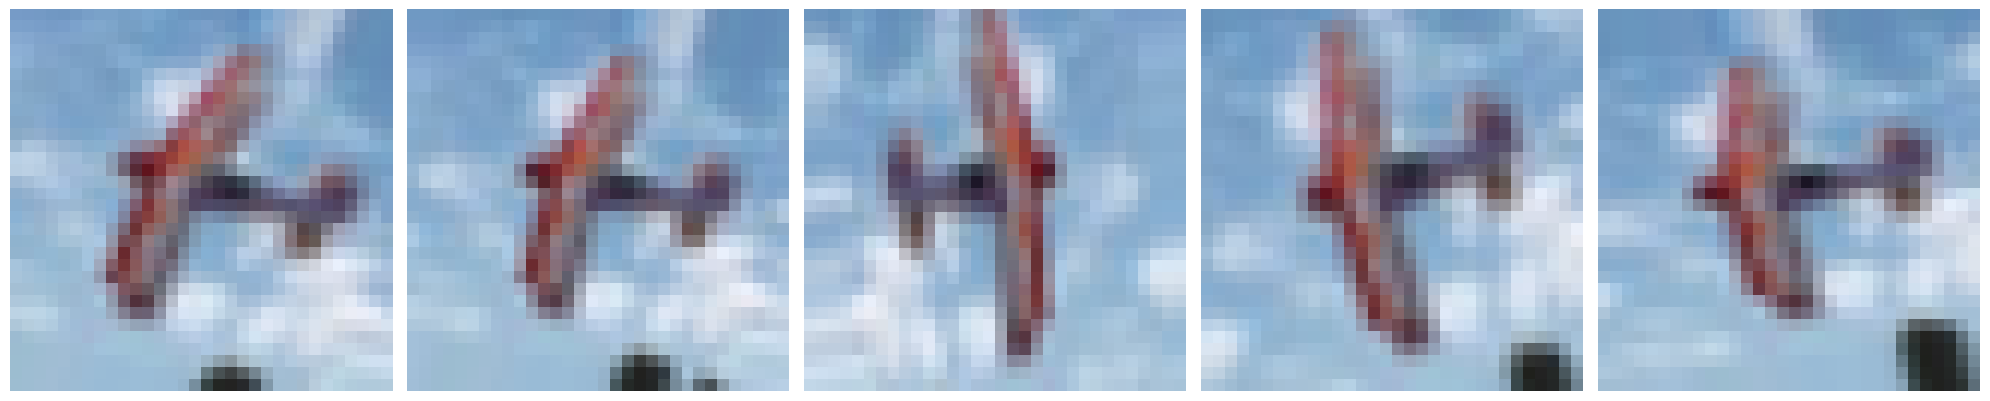

In [ ]:
augmented_images = [new_train_data_gen[0][0][0] for i in range(5)]

fig, axes = plt.subplots(1, 5, figsize=(20,20))
axes = axes.flatten()
for img, ax in zip(augmented_images, axes):
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Dropout
Teknik yang lain untuk mengurangi overfitting adalah menggunakan *dropout* pada network. Dropout adalah sebuah bentuk *regularization* yang memaksa network untuk mengambil weights/bobot yang bernilai kecil, yang membuat distribusi nilai bobot lebih teratur dan network dapat mengurangi overfitting pada data training yang sedikit.

Ketika mengaplikasikan Dropout pada sebuah layer,  ini berarti secara random akan menge-set sejumlah unit pada layer tersebut menjadi NOL selama proses training. Dropout mengambil angka pecahan sebagai nilai inputnya, dalam bentuk seperti 0,1, 0,2, 0,4, dst. Hal ini berarti melakukan dropout pada 10%, 20% atau 40% dari units pada layer tersebut secara random .

Ketika mengaplikasikan dropout 0.1 pada suatu layer tertentu, ini secara random akan mematikan 10% unit output pada setiap epoch.

Kita akan mencoba menerapkan dropout pada network yang kita bangun, terutama pada layer Konvolusi (convolution) dan Fully Connected Layer.

# **7. Membuat CNN dengan Dropouts dan Batch Normalization**
Kita akan menerapkan dropout dengan porsi 25%, berarti bahwa kita akan meng-set 25% dari neuron dengan zero (0) pada setiap epoch pelatihan. Hal ini akan membantu mengurangi overfitting pada training/pelatihan.

Terapkan dropout 25% pada model cnn berikut.

In [ ]:
cnn_model2 = Sequential()

# the first convolutional block
cnn_model2.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_size))
cnn_model2.add(BatchNormalization())
cnn_model2.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
cnn_model2.add(BatchNormalization())
# max pooling
cnn_model2.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model2.add(Dropout(0.25))

# the second convolutional block
cnn_model2.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
cnn_model2.add(BatchNormalization())
cnn_model2.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
cnn_model2.add(BatchNormalization())
# max pooling
cnn_model2.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model2.add(Dropout(0.25))

# the third convolutional block
cnn_model2.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
cnn_model2.add(BatchNormalization())
cnn_model2.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
cnn_model2.add(BatchNormalization())
# max pooling
cnn_model2.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model2.add(Dropout(0.25))

# flatten
cnn_model2.add(Flatten())

# fully connected layer
cnn_model2.add(Dense(128, activation='relu'))
cnn_model2.add(Dropout(0.25))

# last layer
cnn_model2.add(Dense(num_class, activation='softmax'))

### Compile the model
Setelah menambahkan dropout pada network, kita akan compile ulang modelnya.

In [ ]:
# Path to save the best model.
checkpoint_filepath = join(root_path, 'cnn_model2.h5')

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath, save_weights_only=False,
    monitor='val_loss', verbose=1, mode='auto', save_best_only=True)

opt = keras.optimizers.Adam(learning_rate=0.0001)

cnn_model2.compile(optimizer=opt,
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
cnn_model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,29

 Total params: 552,362 (2.11 MB)

 Trainable params: 551,466 (2.10 MB)

 Non-trainable params: 896 (3.50 KB)

### Train the model
Setelah melakukan data augmentation pada data training, kita tambahkan parameter dropout pada network, lalu training kembali network nya:

In [ ]:
epochs = 5

history = cnn_model2.fit(
    new_train_data_gen, # training data yang baru setelah augmentasi
    epochs=epochs,
    validation_data=val_data_gen,
    callbacks=[model_checkpoint_callback],
    verbose=1)

Epoch 1/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.1994 - loss: 2.5214
Epoch 1: val_loss improved from inf to 3.48234, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/Prak04_Data/cnn_model2.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 42s 111ms/step - accuracy: 0.1996 - loss: 2.5201 - val_accuracy: 0.1139 - val_loss: 3.4823
Epoch 2/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.3341 - loss: 1.8370
Epoch 2: val_loss improved from 3.48234 to 1.68295, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/Prak04_Data/cnn_model2.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 22s 80ms/step - accuracy: 0.3342 - loss: 1.8369 - val_accuracy: 0.4032 - val_loss: 1.6829
Epoch 3/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.3920 - loss: 1.6881
Epoch 3: val_loss improved from 1.68295 to 1.49983, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/Prak04_Data/cnn_model2.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - accuracy: 0.3920 - loss: 1.6879 - val_accuracy: 0.4709 - val_loss: 1.4998
Epoch 4/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4303 - loss: 1.5739
Epoch 4: val_loss did not improve from 1.49983
274/274 ━━━━━━━━━━━━━━━━━━━━ 27s 99ms/step - accuracy: 0.4304 - loss: 1.5739 - val_accuracy: 0.4334 - val_loss: 1.7381
Epoch 5/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.4550 - loss: 1.5111
Epoch 5: val_loss improved from 1.49983 to 1.49230, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/Prak04_Data/cnn_model2.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 22s 81ms/step - accuracy: 0.4550 - loss: 1.5111 - val_accuracy: 0.4931 - val_loss: 1.4923


### Visualize training results
Visualisasi hasil training Convolutional Neural Networks

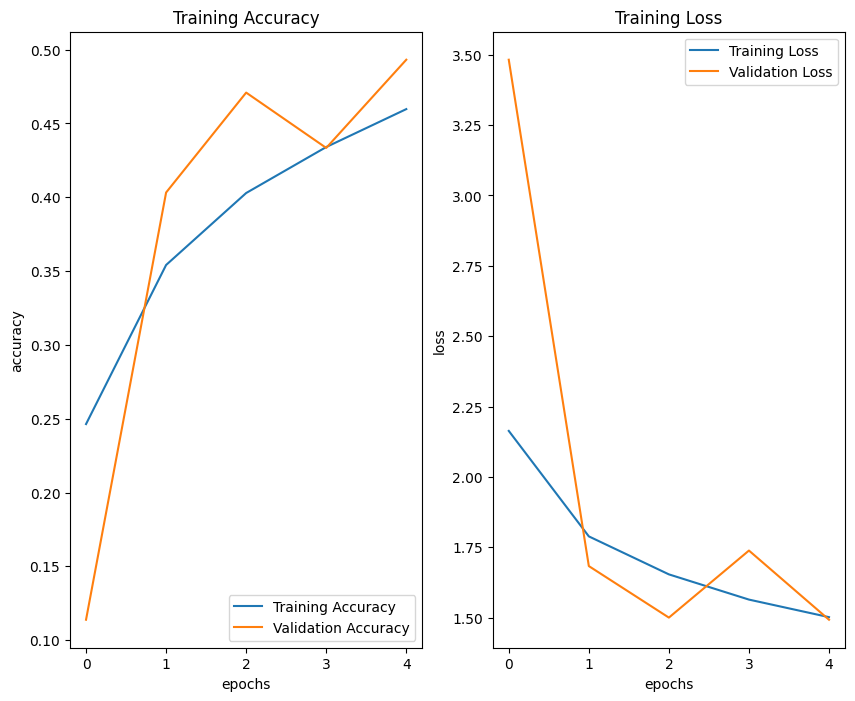

In [ ]:
# ambil statistik pelatihan
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs_range = range(epochs)

# plot hasil akurasi pelatihan
plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.title('Training Accuracy')

# plot hasil loss pelatihan
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.title('Training Loss')
plt.show()

Seperti yang anda lihat pada grafik pelatihan diatas bahwa sudah tidak terjadi overfitting dan validation loss masih turun terus dan validation akurasi masih naik terus sehingga anda dapat menambah jumlah epoch pelatihannya sampai tidak ada perubahan yang signifikan.

# **8. Model Evaluation**

In [ ]:
from tensorflow.keras.models import load_model

# load hasil pelatihan untuk di uji
trained_model = load_model(checkpoint_filepath)

# pengujian dengan data uji
trained_model.evaluate(test_data_gen, verbose=1)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.4979 - loss: 1.4604


[1.4744415283203125, 0.49540001153945923]

## Tampilkan Hasil Pengujian

In [ ]:
from tqdm.notebook import tqdm_notebook

# tampilkan misalnya 20 citra pada dataset
nimages = 5
ncols_plot = 5
nrows_plot = nimages//ncols_plot

y_predict = []
y_actual = []
count_imgs = 0
plot_frame = plt.figure(figsize=(20,10))

# one-by-one prediction
for i in tqdm_notebook(range(len(test_data_gen))):
    imgs, labels = next(test_data_gen)
    labels = np.array(labels, dtype=np.uint8)
    for j in range(len(imgs)):
        X_batch = np.expand_dims(imgs[j], axis=0)
        prediction_scores = trained_model.predict(X_batch)
        score = np.argmax(prediction_scores)
        y_predict.append(score)
        y_actual.append(labels[j])

        # tampilkan 20 hasil pengujian
        if (count_imgs < nimages):
            ax = plot_frame.add_subplot(nrows_plot, ncols_plot, count_imgs+1)
            ax.axis('off')
            ax.set_title("prediksi:" + class_names[score] + \
                        ",  actual:" + class_names[labels[j]])
            plt.imshow(np.uint8(imgs[j]*255))
        count_imgs += 1

y_predict = np.array(y_predict)
y_actual = np.array(y_actual)

## Membuat Confusion Matrix

In [ ]:
import itertools
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# cetak laporan hasil klasifikasi data uji
print('Laporan Klasifikasi Data Uji:')
print(classification_report(y_actual, y_predict))

# hitung confusion matrixnya
conf_mat_result = confusion_matrix(y_actual, y_predict)

# cetak confusion matrix
print('Confusion Matrix:')
print(conf_mat_result)

accuracy = np.trace(conf_mat_result) / np.sum(conf_mat_result).astype('float')
misclass = 1 - accuracy

# masukkan nama kelas di dataset
target_names = class_names
plt.figure(figsize=(8, 8))
cmap = plt.get_cmap('Blues')

plt.imshow(conf_mat_result, interpolation='nearest', cmap=cmap)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=45)
plt.yticks(tick_marks, target_names)

cm = conf_mat_result.astype('float') / conf_mat_result.sum(axis=1)[:, np.newaxis]
thresh = cm.max() / 1.5
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, "{:0.4f}".format(cm[i, j]),
        horizontalalignment='center',
        color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label\naccuracy={:0.4f}; miss={:0.4f}'.format(accuracy, misclass))
plt.show()

# **9. Post Test**
1. Copy kode di **bagian 7: Creating CNN with Dropouts and Batch Normalization** yang sudah anda perbaiki
2. Buat teks baru dibawah kode tersebut dan diberi nama **Model CNN: Post Test**
3. Buat kode baru dibawah teks tersebut lalu paste kode dari Model CNN di soal nomor 1.
4. Ubah nama variabel model tersebut dari **cnn_model2 menjadi cnn_model_posttest**.
5. Ubah nama file untuk menyimpan model dari **cnn_model2.h5 menjadi cnn_model_posttest.h5**.
6. **Modifikasi model CNN tersebut dan tambah jumlah epoch** dan **porsi dropout** sehingga anda bisa mendapatkan akurasi pelatihan, validasi dan pengujian yang lebih tinggi dari model CNN sebelumnya.
7. Jalankan kode untuk pelatihan sampai evaluasi dengan model Post Test yang anda buat.
8. Cermati hasil akurasi pengujiannya!

**Semakin tinggi akurasi yang anda dapatkan dibandingkan dengan hasil akurasi Model CNN sebelumnya maka semakin baik nilai post test anda**

In [ ]:
# Model CNN: Post Test

# Salin kode model dari bagian 7 (Creating CNN with Dropouts and Batch Normalization)
cnn_model_posttest = Sequential()

# the first convolutional block
cnn_model_posttest.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_size))
cnn_model_posttest.add(BatchNormalization())
cnn_model_posttest.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
cnn_model_posttest.add(BatchNormalization())
# max pooling
cnn_model_posttest.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model_posttest.add(Dropout(0.3))  # Ubah porsi dropout

# the second convolutional block
cnn_model_posttest.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
cnn_model_posttest.add(BatchNormalization())
cnn_model_posttest.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
cnn_model_posttest.add(BatchNormalization())
# max pooling
cnn_model_posttest.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model_posttest.add(Dropout(0.3))  # Ubah porsi dropout

# the third convolutional block
cnn_model_posttest.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
cnn_model_posttest.add(BatchNormalization())
cnn_model_posttest.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
cnn_model_posttest.add(BatchNormalization())
# max pooling
cnn_model_posttest.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model_posttest.add(Dropout(0.3))  # Ubah porsi dropout

# Tambah layer Conv2D (opsional)
cnn_model_posttest.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
cnn_model_posttest.add(BatchNormalization())
cnn_model_posttest.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
cnn_model_posttest.add(BatchNormalization())
cnn_model_posttest.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model_posttest.add(Dropout(0.3))  # Ubah porsi dropout

# flatten
cnn_model_posttest.add(Flatten())

# fully connected layer
cnn_model_posttest.add(Dense(128, activation='relu'))
cnn_model_posttest.add(Dropout(0.3))  # Ubah porsi dropout

# last layer
cnn_model_posttest.add(Dense(num_class, activation='softmax'))

# Compile the model
checkpoint_filepath = join(root_path, 'cnn_model_posttest.h5')  # Ubah nama file

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath, save_weights_only=False,
    monitor='val_loss', verbose=1, mode='auto', save_best_only=True)

opt = keras.optimizers.Adam(learning_rate=0.0001)  # Anda dapat mencoba learning rate yang lebih rendah

cnn_model_posttest.compile(optimizer=opt,
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

cnn_model_posttest.summary()

# Train the model
epochs = 30  # Tingkatkan jumlah epoch

# Tambah data augmentation (opsional)
new_train_image_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,  # Tambahkan width shift
    height_shift_range=0.1, # Tambahkan height shift
    horizontal_flip=True,
    zoom_range=0.2)

new_train_data_gen = new_train_image_generator.flow(X_train, y_train,
                                            batch_size=batch_size,
                                            shuffle=True)


history = cnn_model_posttest.fit(
    new_train_data_gen,  # Gunakan data augmentation baru
    epochs=epochs,
    validation_data=val_data_gen,
    callbacks=[model_checkpoint_callback],
    verbose=1)

# ... (kode evaluasi model sama seperti sebelumnya) ...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,308,586 (4.99 MB)

 Trainable params: 1,306,666 (4.98 MB)

 Non-trainable params: 1,920 (7.50 KB)

...

274/274 ━━━━━━━━━━━━━━━━━━━━ 24s 87ms/step - accuracy: 0.5430 - loss: 1.2876 - val_accuracy: 0.5359 - val_loss: 1.3832
Epoch 15/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5560 - loss: 1.2468
Epoch 15: val_loss did not improve from 1.38316
274/274 ━━━━━━━━━━━━━━━━━━━━ 23s 84ms/step - accuracy: 0.5560 - loss: 1.2468 - val_accuracy: 0.5102 - val_loss: 1.5389
Epoch 16/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5680 - loss: 1.2277
Epoch 16: val_loss did not improve from 1.38316
274/274 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.5680 - loss: 1.2277 - val_accuracy: 0.5213 - val_loss: 1.4540
Epoch 17/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5648 - loss: 1.2273
Epoch 17: val_loss did not improve from 1.38316
274/274 ━━━━━━━━━━━━━━━━━━━━ 23s 84ms/step - accuracy: 0.5648 - loss: 1.2273 - val_accuracy: 0.5203 - val_loss: 1.4801
Epoch 18/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5812 - loss: 1.1743
Epoch 18: val_loss did not i

274/274 ━━━━━━━━━━━━━━━━━━━━ 24s 88ms/step - accuracy: 0.5813 - loss: 1.1745 - val_accuracy: 0.5818 - val_loss: 1.2011
Epoch 20/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.5978 - loss: 1.1441
Epoch 20: val_loss did not improve from 1.20106
274/274 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.5978 - loss: 1.1441 - val_accuracy: 0.5881 - val_loss: 1.2113
Epoch 21/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6109 - loss: 1.1185
Epoch 21: val_loss did not improve from 1.20106
274/274 ━━━━━━━━━━━━━━━━━━━━ 23s 85ms/step - accuracy: 0.6109 - loss: 1.1185 - val_accuracy: 0.5820 - val_loss: 1.2327
Epoch 22/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.6106 - loss: 1.1018
Epoch 22: val_loss improved from 1.20106 to 1.13202, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/Prak04_Data/cnn_model_posttest.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 24s 88ms/step - accuracy: 0.6106 - loss: 1.1018 - val_accuracy: 0.6121 - val_loss: 1.1320
Epoch 23/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6269 - loss: 1.0651
Epoch 23: val_loss did not improve from 1.13202
274/274 ━━━━━━━━━━━━━━━━━━━━ 25s 90ms/step - accuracy: 0.6269 - loss: 1.0651 - val_accuracy: 0.5969 - val_loss: 1.1972
Epoch 24/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6236 - loss: 1.0677
Epoch 24: val_loss improved from 1.13202 to 1.08662, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/Prak04_Data/cnn_model_posttest.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 24s 88ms/step - accuracy: 0.6236 - loss: 1.0676 - val_accuracy: 0.6331 - val_loss: 1.0866
Epoch 25/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6315 - loss: 1.0566
Epoch 25: val_loss did not improve from 1.08662
274/274 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.6315 - loss: 1.0565 - val_accuracy: 0.6083 - val_loss: 1.1751
Epoch 26/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6390 - loss: 1.0326
Epoch 26: val_loss did not improve from 1.08662
274/274 ━━━━━━━━━━━━━━━━━━━━ 23s 84ms/step - accuracy: 0.6390 - loss: 1.0326 - val_accuracy: 0.6127 - val_loss: 1.1576
Epoch 27/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6442 - loss: 1.0185
Epoch 27: val_loss improved from 1.08662 to 1.01813, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/Prak04_Data/cnn_model_posttest.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 25s 91ms/step - accuracy: 0.6442 - loss: 1.0185 - val_accuracy: 0.6549 - val_loss: 1.0181
Epoch 28/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6522 - loss: 0.9869
Epoch 28: val_loss did not improve from 1.01813
274/274 ━━━━━━━━━━━━━━━━━━━━ 24s 86ms/step - accuracy: 0.6522 - loss: 0.9869 - val_accuracy: 0.6382 - val_loss: 1.0636
Epoch 29/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.6584 - loss: 0.9763
Epoch 29: val_loss did not improve from 1.01813
274/274 ━━━━━━━━━━━━━━━━━━━━ 24s 86ms/step - accuracy: 0.6584 - loss: 0.9763 - val_accuracy: 0.6370 - val_loss: 1.0739
Epoch 30/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6553 - loss: 0.9671
Epoch 30: val_loss did not improve from 1.01813
274/274 ━━━━━━━━━━━━━━━━━━━━ 24s 87ms/step - accuracy: 0.6553 - loss: 0.9671 - val_accuracy: 0.6416 - val_loss: 1.0441
